<a href="https://colab.research.google.com/github/fangyuan007t/Fake-News-Detection/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()  # Upload Fake.csv and True.csv

Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [ ]:
!pip install tensorflow seaborn

import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [ ]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true]).sample(frac=1, random_state=42).reset_index(drop=True)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text"] = df["text"].apply(clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42
)

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2),
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)

preds_lr = lr.predict(X_test_vec)

lr_acc = accuracy_score(y_test, preds_lr)
lr_precision = precision_score(y_test, preds_lr)
lr_recall = recall_score(y_test, preds_lr)
lr_f1 = f1_score(y_test, preds_lr)

print("LR Accuracy:", lr_acc)

LR Accuracy: 0.9920935412026726


In [ ]:
vocab_size = 5000
max_len = 200

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

model = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(
    X_train_pad,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.1
)

preds_lstm = (model.predict(X_test_pad) > 0.5).astype("int32")

lstm_acc = accuracy_score(y_test, preds_lstm)
lstm_precision = precision_score(y_test, preds_lstm)
lstm_recall = recall_score(y_test, preds_lstm)
lstm_f1 = f1_score(y_test, preds_lstm)

print("LSTM Accuracy:", lstm_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 109s 103ms/step - accuracy: 0.8805 - loss: 0.2775 - val_accuracy: 0.9697 - val_loss: 0.1115
Epoch 2/3
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 101s 100ms/step - accuracy: 0.9315 - loss: 0.1714 - val_accuracy: 0.9677 - val_loss: 0.1117
Epoch 3/3
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 102s 101ms/step - accuracy: 0.9626 - loss: 0.1166 - val_accuracy: 0.9733 - val_loss: 0.0939
281/281 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step
LSTM Accuracy: 0.97271714922049


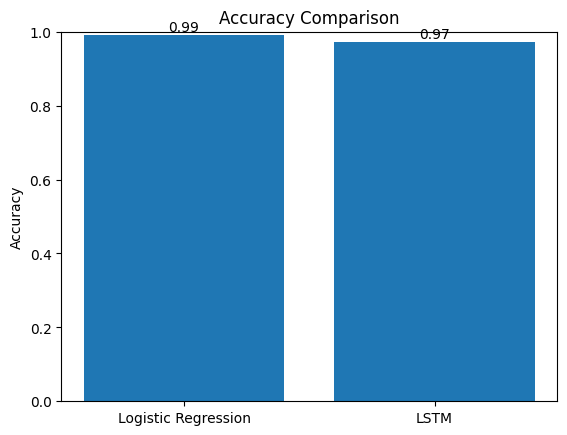

In [ ]:
models = ["Logistic Regression", "LSTM"]
accuracies = [lr_acc, lstm_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

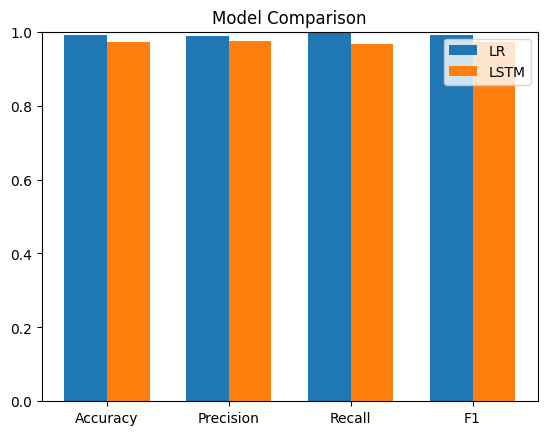

In [ ]:
labels = ["Accuracy", "Precision", "Recall", "F1"]

lr_scores = [lr_acc, lr_precision, lr_recall, lr_f1]
lstm_scores = [lstm_acc, lstm_precision, lstm_recall, lstm_f1]

x = np.arange(len(labels))
width = 0.35

plt.figure()

plt.bar(x - width/2, lr_scores, width, label="LR")
plt.bar(x + width/2, lstm_scores, width, label="LSTM")

plt.xticks(x, labels)
plt.ylim(0, 1)
plt.title("Model Comparison")
plt.legend()

plt.show()

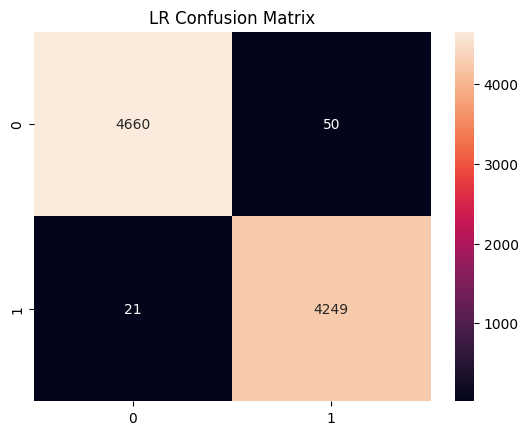

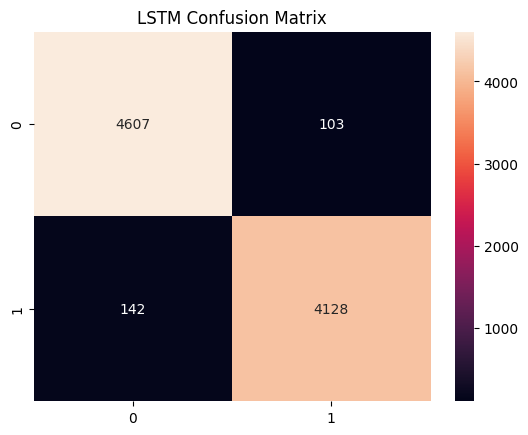

In [ ]:
cm_lr = confusion_matrix(y_test, preds_lr)
cm_lstm = confusion_matrix(y_test, preds_lstm)

plt.figure()
sns.heatmap(cm_lr, annot=True, fmt="d")
plt.title("LR Confusion Matrix")
plt.show()

plt.figure()
sns.heatmap(cm_lstm, annot=True, fmt="d")
plt.title("LSTM Confusion Matrix")
plt.show()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Create model
model = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 🔥 Add EarlyStopping HERE (before training)
early_stop = EarlyStopping(
    patience=2,                # stops if no improvement for 2 epochs
    restore_best_weights=True  # restores best model automatically
)

# 🚀 Replace your old model.fit with this
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,                 # can keep high, it will stop early anyway
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]     # 👈 THIS is the key line
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1011/1011 ━━━━━━━━━━━━━━━━━━━━ 99s 95ms/step - accuracy: 0.8718 - loss: 0.3185 - val_accuracy: 0.8611 - val_loss: 0.3133
Epoch 2/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 98s 96ms/step - accuracy: 0.8744 - loss: 0.2521 - val_accuracy: 0.8995 - val_loss: 0.2664
Epoch 3/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 144s 98ms/step - accuracy: 0.8969 - loss: 0.2257 - val_accuracy: 0.9396 - val_loss: 0.1382
Epoch 4/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 98s 97ms/step - accuracy: 0.9786 - loss: 0.0717 - val_accuracy: 0.9825 - val_loss: 0.0696
Epoch 5/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 96s 95ms/step - accuracy: 0.9912 - loss: 0.0362 - val_accuracy: 0.9822 - val_loss: 0.0567
Epoch 6/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 140s 94ms/step - accuracy: 0.9958 - loss: 0.0195 - val_accuracy: 0.9841 - val_loss: 0.0589
Epoch 7/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 95s 94ms/step - accuracy: 0.9981 - loss: 0.0113 - val_accuracy: 0.9855 - val_loss: 0.0547
Epoch 8/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 94s 93ms/step - accuracy: 0.9986 - loss: 0.

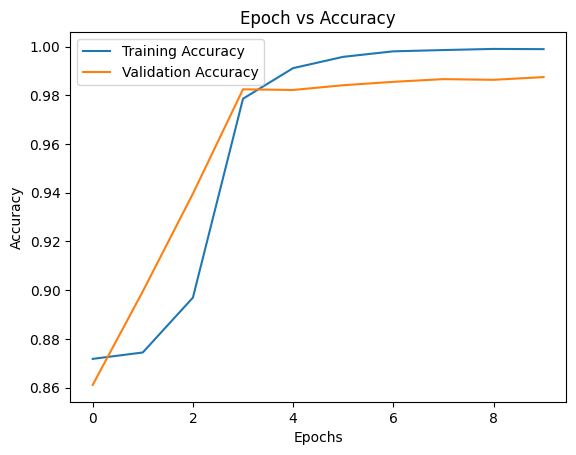

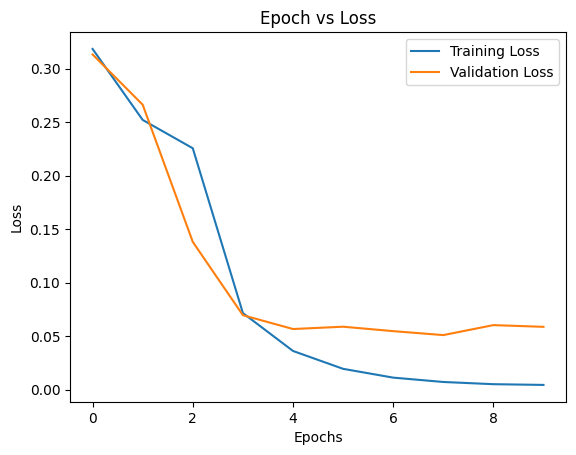

In [ ]:
# Accuracy Graph
plt.figure()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Epoch vs Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


# Loss Graph
plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Epoch vs Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()